# Part II: Determinants of ESG Performance

This section examines which firm-level characteristics predict ESG scores in the cross-section. Understanding what drives ESG performance matters for two reasons. First, if ESG scores primarily reflect firm size or industry affiliation, they carry less independent information about a firm's underlying sustainability practices. Second, identifying the structural determinants of ESG performance can inform both corporate decision-making and investor portfolio construction.

We examine six firm characteristics motivated by the empirical ESG literature. Firm size is the most consistently documented predictor: larger firms face greater public scrutiny, maintain dedicated resources for ESG programs, and bear higher reputational costs from poor ESG outcomes (Starks, 2023; Khan, Serafeim, and Yoon, 2016). Profitability, measured by return on assets, relates to the slack resources hypothesis, whereby firms with stronger earnings have more discretionary capacity to invest in ESG initiatives. Financial leverage captures the degree to which debt financing constrains or shapes managerial priorities; however, its relationship with ESG is complicated by the fact that highly regulated industries such as utilities are simultaneously capital-intensive, highly leveraged, and among the highest ESG scorers. Research and development intensity is often associated with innovation-oriented cultures and governance practices, though its unconditional relationship with ESG is complicated by sector composition effects, particularly the pharmaceutical industry, which combines the highest R&D spending in the sample with the lowest ESG scores. Capital intensity, measured as net property, plant and equipment scaled by total assets, proxies for exposure to physical environmental risks and associated regulatory pressures. Finally, sales growth captures firm dynamism, with rapidly growing firms potentially lacking the organizational capacity to sustain mature ESG programs.

The analysis proceeds as follows. Section 1 defines all variables and reports summary statistics. Section 2 presents univariate relationships between each characteristic and ESG scores using decile-sorted mean plots and a pairwise correlation matrix. Section 3 reports ordinary least squares regressions of ESG scores on firm characteristics, progressively adding year and industry fixed effects. Section 4 examines how the determinants of ESG performance vary across industries.

In [3]:
# !pip install --quiet statsmodels seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.formula.api as smf
from IPython.display import display

try:
    import seaborn as sns
    HAS_SEABORN = True
except ImportError:
    HAS_SEABORN = False

# Load the panel produced by data_prepare.ipynb.
# This notebook requires the extended CSV that includes dltt, dlc, xrd, and ppent.
# If those columns are missing, re-run data_prepare.ipynb first.
panel = pd.read_csv('esg_financial_panel_2013_2023.csv')
panel['datadate'] = pd.to_datetime(panel['datadate'])
panel['sic'] = pd.to_numeric(panel['sic'], errors='coerce')

required_ext = ['dltt', 'dlc', 'xrd', 'ppent']
missing_ext = [c for c in required_ext if c not in panel.columns]
if missing_ext:
    raise ValueError(
        f"Columns {missing_ext} are missing. "
        "Please re-run data_prepare.ipynb to regenerate "
        "esg_financial_panel_2013_2023.csv with the extended variable set."
    )

print(f'Loaded: {len(panel):,} firm-year observations')
print(f'Columns: {list(panel.columns)}')

Loaded: 20,758 firm-year observations
Columns: ['gvkey', 'permno', 'datadate', 'fyear', 'cusip8', 'sic', 'at', 'sale', 'ni', 'ceq', 'dltt', 'dlc', 'xrd', 'ppent', 'roa', 'size', 'lag_roa', 'lag_size', 'esg_score', 'future_roa', 'future_annual_ret', 'future_n_months_ret']


## 1. Variable Construction

We construct the following firm characteristics from Compustat data. Firm size is the natural logarithm of total assets, already present in the panel from the data preparation stage. Return on assets is net income scaled by total assets, also carried over from the panel. Leverage is the sum of long-term debt and debt in current liabilities, scaled by total assets; firms with missing debt values are assigned zero, on the assumption that non-reporting reflects the absence of recorded debt. Research and development intensity is R&D expense scaled by total assets; firms that do not report R&D expense are assigned zero, following standard practice in the empirical innovation literature. Capital intensity is net property, plant and equipment scaled by total assets. The equity ratio is common equity scaled by total assets and can take negative values for firms with negative book equity. Profit margin is net income scaled by net sales, computed only for firm-years with positive sales to avoid division by zero or sign reversals from negative revenue. Sales growth is the year-over-year percentage change in sales revenue, computed relative to the prior fiscal year within each firm and restricted to firm-years where lagged sales are positive.

All derived continuous variables are winsorized at the 1st and 99th percentiles to limit the influence of extreme observations on regression estimates and correlation statistics.

In [4]:
# Fama-French 48 industry classification, consistent with part1.ipynb
# Source: https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/Data_Library/det_48_ind_port.html
FF48 = [
    (1,  'Agriculture',              [(100,199),(200,299),(700,799),(910,919),(2048,2048)]),
    (2,  'Food Products',            [(2000,2046),(2050,2063),(2070,2079),(2086,2086),(2090,2092),(2095,2095),(2096,2096),(2097,2099)]),
    (3,  'Candy & Soda',             [(2064,2068),(2086,2086),(2096,2096),(2097,2097)]),
    (4,  'Beer & Liquor',            [(2080,2085),(2080,2080)]),
    (5,  'Tobacco Products',         [(2100,2199)]),
    (6,  'Recreation',               [(7800,7833),(7840,7841),(7900,7999),(7993,7993),(7997,7997)]),
    (7,  'Entertainment',            [(7812,7819),(7820,7823),(7824,7829)]),
    (8,  'Printing & Publishing',    [(2700,2749),(2770,2771),(2780,2799)]),
    (9,  'Consumer Goods',           [(2047,2047),(2391,2392),(2510,2519),(2590,2599),(2840,2844),(2846,2849),(3160,3162),(3170,3172),(3190,3199),(3229,3229),(3260,3260),(3262,3263),(3269,3269),(3630,3639),(3750,3751),(3800,3800),(3860,3861),(3870,3879),(3910,3919),(3960,3969),(3991,3991),(3995,3995)]),
    (10, 'Apparel',                  [(2300,2390),(3020,3021),(3100,3111),(3130,3131),(3140,3149),(3150,3151),(3963,3965)]),
    (11, 'Healthcare',               [(8000,8099)]),
    (12, 'Medical Equipment',        [(3841,3851),(3841,3841),(3842,3842),(3843,3843),(3844,3844),(3845,3845),(3851,3851),(5047,5047),(5122,5122)]),
    (13, 'Pharmaceutical Products',  [(2830,2836)]),
    (14, 'Chemicals',                [(2800,2829),(2850,2879),(2890,2899)]),
    (15, 'Rubber & Plastic',         [(3000,3030),(3041,3041),(3050,3053),(3060,3069),(3070,3079),(3080,3089),(3090,3099)]),
    (16, 'Textiles',                 [(2200,2284),(2290,2295),(2297,2299),(2393,2395),(2397,2399)]),
    (17, 'Construction Materials',   [(800,899),(1500,1511),(1520,1542),(1550,1559),(1600,1699),(1711,1799),(2400,2439),(2450,2459),(2490,2499),(2660,2661),(2950,2952),(3200,3200),(3210,3211),(3240,3241),(3250,3259),(3261,3261),(3264,3264),(3270,3275),(3280,3281),(3290,3293),(3295,3299),(3420,3429),(3430,3433),(3440,3441),(3442,3442),(3446,3446),(3448,3448),(3449,3449),(3460,3469),(3490,3499),(3996,3996)]),
    (18, 'Steel Works',              [(3300,3300),(3310,3317),(3320,3325),(3330,3341),(3350,3357),(3360,3369),(3390,3399)]),
    (19, 'Fabricated Products',      [(3410,3412),(3443,3443),(3444,3444),(3460,3462),(3490,3492),(3494,3495),(3496,3499)]),
    (20, 'Machinery',                [(3510,3519),(3520,3529),(3530,3539),(3540,3549),(3550,3559),(3560,3569),(3580,3589),(3590,3599)]),
    (21, 'Electrical Equipment',     [(3600,3600),(3610,3613),(3620,3621),(3623,3629),(3640,3646),(3648,3649),(3660,3660),(3690,3692),(3699,3699)]),
    (22, 'Automobiles & Trucks',     [(2296,2296),(2396,2396),(3010,3011),(3537,3537),(3647,3647),(3694,3694),(3700,3716),(3750,3751),(3790,3792),(3799,3799)]),
    (23, 'Aircraft',                 [(3720,3721),(3723,3725),(3728,3729)]),
    (24, 'Shipbuilding',             [(3730,3731),(3740,3743)]),
    (25, 'Defense',                  [(3760,3769),(3480,3489),(3812,3812)]),
    (26, 'Precious Metals',          [(1040,1049)]),
    (27, 'Non-Metallic Mining',      [(1000,1039),(1050,1099),(1400,1499)]),
    (28, 'Coal',                     [(1200,1299)]),
    (29, 'Petroleum & Natural Gas',  [(1300,1399),(2900,2912),(2990,2999)]),
    (30, 'Utilities',                [(4900,4942),(4950,4952),(4953,4953),(4959,4959),(4961,4961),(4991,4991)]),
    (31, 'Communication',            [(4800,4899)]),
    (32, 'Personal Services',        [(7020,7021),(7040,7041),(7080,7081),(7200,7299),(7300,7300),(7389,7389),(7395,7395),(7500,7521),(7532,7534),(7536,7599),(7600,7641),(7690,7699),(8200,8499),(8600,8699),(8800,8899),(7510,7515)]),
    (33, 'Business Services',        [(7370,7379),(7380,7399),(7514,7515),(7519,7519),(8700,8748),(8900,8999),(4220,4229)]),
    (34, 'Computers',                [(3570,3579),(3680,3689),(3695,3695),(7373,7373)]),
    (35, 'Electronic Equipment',     [(3622,3622),(3661,3669),(3670,3679),(3810,3810),(3812,3812)]),
    (36, 'Measuring Instruments',    [(3811,3811),(3820,3829),(3830,3839)]),
    (37, 'Misc. Business',           [(3900,3999)]),
    (38, 'Transportation',           [(4000,4013),(4040,4049),(4100,4231),(4400,4499),(4600,4621),(4700,4789)]),
    (39, 'Wholesale',                [(5000,5199)]),
    (40, 'Retail',                   [(5200,5999)]),
    (41, 'Restaurants & Hotels',     [(5800,5829),(5890,5899),(7000,7011),(7041,7041)]),
    (42, 'Banking',                  [(6000,6199)]),
    (43, 'Insurance',                [(6300,6411)]),
    (44, 'Real Estate',              [(6500,6515),(6552,6553),(6798,6798)]),
    (45, 'Trading',                  [(6200,6299),(6710,6799)]),
]

sic_to_ff48 = {}
for ff_id, ff_name, ranges in FF48:
    for lo, hi in ranges:
        for s in range(lo, hi + 1):
            if s not in sic_to_ff48:
                sic_to_ff48[s] = (ff_id, ff_name)

def assign_ff48(sic):
    if pd.isna(sic):
        return (48, 'Other')
    return sic_to_ff48.get(int(sic), (48, 'Other'))

ff48_result = panel['sic'].apply(assign_ff48)
panel['ff48_id']  = ff48_result.apply(lambda x: x[0]).astype(int)
panel['industry'] = ff48_result.apply(lambda x: x[1])

print(f"Industry assignment complete. Unclassified: {(panel['industry'] == 'Other').sum():,} "
      f"({(panel['industry'] == 'Other').mean() * 100:.1f}%)")

Industry assignment complete. Unclassified: 1,009 (4.9%)


In [5]:
# Sort panel for computing lags within each firm
panel = panel.sort_values(['gvkey', 'fyear']).copy()

# Leverage: total debt (long-term + current) scaled by total assets.
# Missing debt fields are set to zero on the assumption that non-reporting
# reflects the absence of recorded debt obligations (consistent with, e.g.,
# Rajan and Zingales, 1995).
panel['leverage'] = (
    panel['dltt'].fillna(0) + panel['dlc'].fillna(0)
) / panel['at']

# R&D intensity: R&D expense scaled by total assets.
# Firms that do not report xrd are assigned zero, following the convention
# established in the innovation and intangibles literature.
panel['rd_intensity'] = panel['xrd'].fillna(0) / panel['at']

# Capital intensity: net PP&E scaled by total assets.
# Captures the degree to which a firm's asset base consists of tangible
# physical capital subject to environmental regulations.
panel['capital_intensity'] = panel['ppent'].fillna(0) / panel['at']

# Equity ratio: common equity scaled by total assets.
# Reflects balance sheet health; negative values occur for firms with
# accumulated losses exceeding paid-in capital.
panel['equity_ratio'] = panel['ceq'] / panel['at']

# Profit margin: net income scaled by net sales.
# Restricted to firm-years with positive sales to avoid undefined or
# economically uninterpretable values.
panel['profit_margin'] = np.where(
    panel['sale'] > 0,
    panel['ni'] / panel['sale'],
    np.nan
)

# Sales growth: year-over-year percentage change in net sales.
# Lagged sales are computed within each firm. Firm-years where
# lagged sales are non-positive are excluded.
panel['lag_sale'] = panel.groupby('gvkey')['sale'].shift(1)
panel['sales_growth'] = np.where(
    panel['lag_sale'] > 0,
    (panel['sale'] - panel['lag_sale']) / panel['lag_sale'],
    np.nan
)

# Report coverage for derived variables
new_vars = ['leverage', 'rd_intensity', 'capital_intensity',
            'equity_ratio', 'profit_margin', 'sales_growth']
print('Non-missing observations for derived variables:')
for v in new_vars:
    print(f'  {v:<22}: {panel[v].notna().sum():>6,}')

Non-missing observations for derived variables:
  leverage              : 20,758
  rd_intensity          : 20,758
  capital_intensity     : 20,758
  equity_ratio          : 20,758
  profit_margin         : 20,199
  sales_growth          : 16,996


In [6]:
def winsorize(series, lower=0.01, upper=0.99):
    """Winsorize a pandas Series at the specified quantile bounds."""
    lo = series.quantile(lower)
    hi = series.quantile(upper)
    return series.clip(lo, hi)

# roa and size are raw in the CSV (winsorization in part1.ipynb was in-memory only).
# All derived variables are winsorized here before use in any table or regression.
winsorize_vars = [
    'roa', 'size',
    'leverage', 'rd_intensity', 'capital_intensity',
    'equity_ratio', 'profit_margin', 'sales_growth',
]
for v in winsorize_vars:
    panel[v] = winsorize(panel[v])

print('Winsorization complete (1st and 99th percentiles).')

Winsorization complete (1st and 99th percentiles).


## 2. Summary Statistics

Table 1 reports descriptive statistics for the firm characteristics used in this analysis. The statistics are computed over all firm-year observations in the final sample, after winsorizing at the 1st and 99th percentiles. Sample sizes differ across variables because profit margin and sales growth require positive sales and at least two consecutive fiscal years of data within a firm, respectively.

In [7]:
vars_p2 = [
    'esg_score', 'size', 'roa',
    'leverage', 'rd_intensity', 'capital_intensity',
    'equity_ratio', 'profit_margin', 'sales_growth',
]

var_labels = {
    'esg_score':         'ESG Score',
    'size':              'Size (log AT)',
    'roa':               'Return on Assets',
    'leverage':          'Leverage',
    'rd_intensity':      'R&D Intensity',
    'capital_intensity': 'Capital Intensity',
    'equity_ratio':      'Equity Ratio',
    'profit_margin':     'Profit Margin',
    'sales_growth':      'Sales Growth',
}

summary = panel[vars_p2].describe().T
summary = summary[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]
summary.index = [var_labels[v] for v in vars_p2]
summary.columns = ['N', 'Mean', 'Std', 'Min', 'P25', 'Median', 'P75', 'Max']
summary['N'] = summary['N'].astype(int)
summary = summary.round(4)

print('Table 1: Summary Statistics for Firm Characteristics')
display(summary)

Table 1: Summary Statistics for Firm Characteristics


,N,Mean,Std,Min,P25,Median,P75,Max
ESG Score,20758,0.4042,0.1909,0.0696,0.2538,0.3735,0.5387,0.8542
Size (log AT),20758,7.8682,1.8676,3.6663,6.5893,7.8056,9.0540,12.6008
Return on Assets,20756,-0.0063,0.1701,-0.8335,-0.0056,0.0243,0.0699,0.2933
Leverage,20758,0.2641,0.2239,0.0000,0.0720,0.2293,0.3972,1.0197
R&D Intensity,20758,0.0464,0.0994,0.0000,0.0000,0.0000,0.0416,0.5535
Capital Intensity,20758,0.2070,0.2317,0.0000,0.0320,0.1138,0.2972,0.8781
Equity Ratio,20758,0.3795,0.2725,-0.4540,0.1645,0.3717,0.5666,0.9395
Profit Margin,20199,-0.5343,3.8718,-34.6039,0.0007,0.0634,0.1469,0.4999
Sales Growth,16996,0.1304,0.3488,-0.6063,-0.0083,0.0738,0.1887,2.2929


Table 1 documents the distribution of firm characteristics across the 20,758 firm-year observations in the final sample. The mean ESG score is 0.404 with a standard deviation of 0.191, confirming the substantial cross-sectional variation documented in Part I.

Firm size, measured as log total assets, has a mean of 7.87 and a standard deviation of 1.87, consistent with a sample tilted toward larger listed firms. Return on assets has a mean of -0.006 and a median of 0.024, indicating that a sub-set of loss-making firms pulls the average below zero while the typical firm is modestly profitable.

Leverage, defined as total debt scaled by total assets, has a mean of 0.264. The distribution is roughly symmetric around the median of 0.229, with about a quarter of firms carrying leverage above 0.397. R&D intensity is heavily right-skewed: the median is zero because 55 percent of sample firms report no R&D expense, while a small number of firms in technology, pharmaceuticals, and medical equipment reach values above 0.5. Capital intensity has a mean of 0.207 and a median of 0.114, reflecting a sample that mixes asset-heavy sectors such as utilities and petroleum with asset-light sectors such as finance and business services.

Profit margin has a mean of -0.534 but a median of 0.063, indicating extreme left-skew driven by firms with deep losses. After winsorization at the 1st and 99th percentiles, the range spans from -34.6 to 0.5. Sales growth has a mean of 0.130 and a median of 0.074. The lower observation count for these two variables (20,199 and 16,996, respectively) reflects the requirement for positive prior-year sales data.

## 3. Univariate Analysis

Before turning to multivariate regressions, we examine the unconditional relationship between each firm characteristic and ESG scores. Figure 1 uses a decile-sort approach: for each characteristic, we assign firm-years to deciles based on that characteristic and plot the mean ESG score within each decile. This approach highlights nonlinear patterns that a single correlation coefficient would obscure. Figure 2 presents a pairwise correlation matrix for all variables to assess multicollinearity among the regressors.

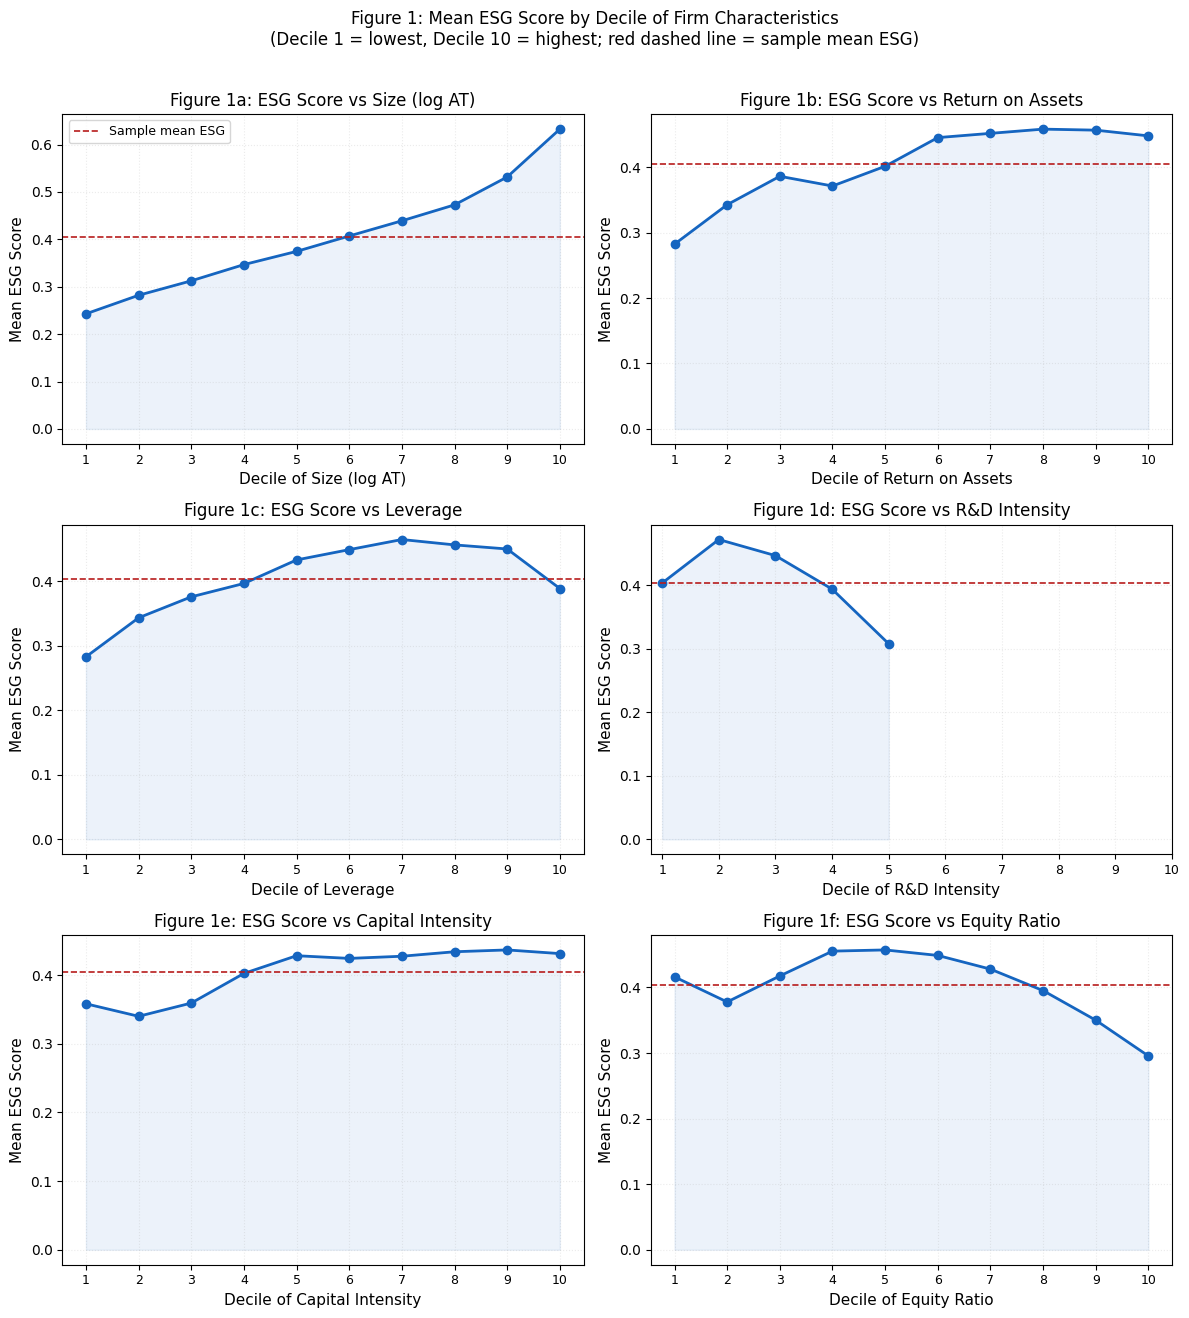

Figure 1 saved to part2_figure1_decile_means.png


In [8]:
char_vars = [
    ('size',              'Size (log AT)'),
    ('roa',               'Return on Assets'),
    ('leverage',          'Leverage'),
    ('rd_intensity',      'R&D Intensity'),
    ('capital_intensity', 'Capital Intensity'),
    ('equity_ratio',      'Equity Ratio'),
]

fig, axes = plt.subplots(3, 2, figsize=(12, 13))
axes = axes.flatten()

panel_labels = list('abcdef')

for i, (var, label) in enumerate(char_vars):
    ax = axes[i]
    tmp = panel[['esg_score', var]].dropna().copy()
    tmp['decile'] = pd.qcut(tmp[var], q=10, labels=False, duplicates='drop') + 1
    binned = tmp.groupby('decile')['esg_score'].mean().reset_index()

    ax.plot(
        binned['decile'], binned['esg_score'],
        marker='o', color='#1565C0', linewidth=2, markersize=6
    )
    ax.fill_between(binned['decile'], binned['esg_score'], alpha=0.08, color='#1565C0')

    # Add a horizontal reference line at the overall sample mean ESG
    ax.axhline(panel['esg_score'].mean(), linestyle='--', color='#B71C1C',
               linewidth=1.2, label='Sample mean ESG')

    ax.set_xlabel(f'Decile of {label}', fontsize=11)
    ax.set_ylabel('Mean ESG Score', fontsize=11)
    ax.set_title(
        f'Figure 1{panel_labels[i]}: ESG Score vs {label}', fontsize=12
    )
    ax.set_xticks(range(1, 11))
    ax.set_xticklabels([str(j) for j in range(1, 11)], fontsize=9)
    ax.grid(True, alpha=0.25, linestyle=':')
    if i == 0:
        ax.legend(fontsize=9)

plt.suptitle(
    'Figure 1: Mean ESG Score by Decile of Firm Characteristics\n'
    '(Decile 1 = lowest, Decile 10 = highest; red dashed line = sample mean ESG)',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig('part2_figure1_decile_means.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure 1 saved to part2_figure1_decile_means.png')

Figure 1 reveals that the six firm characteristics relate to ESG scores in ways that are not always consistent with simple theoretical priors.

The relationship between firm size and ESG scores (Panel 1a) is strongly and nearly monotonically positive: firms in the top size decile score an average of 0.633 on ESG, compared to 0.243 for firms in the bottom decile, a spread of 0.390 score points. This is by far the largest univariate gradient in the data and underscores that size is the dominant correlate of ESG performance.

The ROA-ESG relationship (Panel 1b) is broadly positive, with mean ESG rising from 0.282 in the lowest ROA decile to 0.448 in the highest, a spread of 0.166 points. The pattern is not perfectly monotonic: there is a dip at the fourth decile before scores rise consistently through deciles five to ten. Overall the gradient is consistent with the slack resources hypothesis.

Leverage (Panel 1c) shows a hump-shaped pattern: mean ESG rises from 0.283 in the lowest leverage decile to a peak of 0.465 at the seventh decile, then declines to 0.389 in the highest leverage decile. This non-monotonic pattern reflects the coexistence of two distinct groups of leveraged firms: regulated industries such as utilities and restaurants, which carry high debt and score well on ESG, and financially distressed or speculative firms at the extreme high end of leverage, which score lower. The overall positive correlation between leverage and ESG (0.133) is therefore largely a compositional artifact of industry structure.

R&D intensity (Panel 1d) produces only five quantile groups rather than ten because 55 percent of sample firms report zero R&D expense, creating a mass point that prevents the formation of ten distinct bins. Among the bins that do form, the relationship is hump-shaped: zero-R&D firms in the first bin average an ESG score of 0.404, firms with very low positive R&D spending in the second bin score the highest at 0.472, and the score then declines monotonically to 0.308 in the highest R&D bin. The overall negative gradient from the second bin onward is almost entirely driven by the pharmaceutical industry, which has the highest R&D intensity in the sample (mean 0.246) and the lowest mean ESG score (0.322). Pharmaceutical firms face persistent criticism over drug pricing, access to medicines, and governance controversies, which suppresses their ESG scores despite their innovation activity. As shown in Section 3, once industry fixed effects are included in regressions, R&D intensity carries a positive and significant coefficient within industries, confirming that the negative unconditional gradient is a composition effect.

Capital intensity (Panel 1e) shows a threshold effect: firms with the lowest capital intensity (near-zero PP&E scaled by assets) score around 0.358 on ESG, dip slightly to 0.340 in the second decile, then rise from the third decile onward and stabilize in the range of 0.42 to 0.43 for the upper half of the distribution. Asset-heavy firms in regulated sectors face greater scrutiny over their physical environmental footprint, which creates stronger incentives for ESG investment and disclosure.

The equity ratio (Panel 1f) displays another inverted-U: ESG scores peak around the fourth and fifth deciles (0.455 to 0.457), then decline sharply in the top deciles, reaching 0.296 at the highest equity ratio decile. Firms with very high equity ratios tend to be loss-making growth companies in sectors such as pharmaceuticals and technology, which combine strong balance sheets with low ESG scores. The resulting negative pairwise correlation (-0.112) reflects this composition effect rather than a genuine negative within-industry relationship.

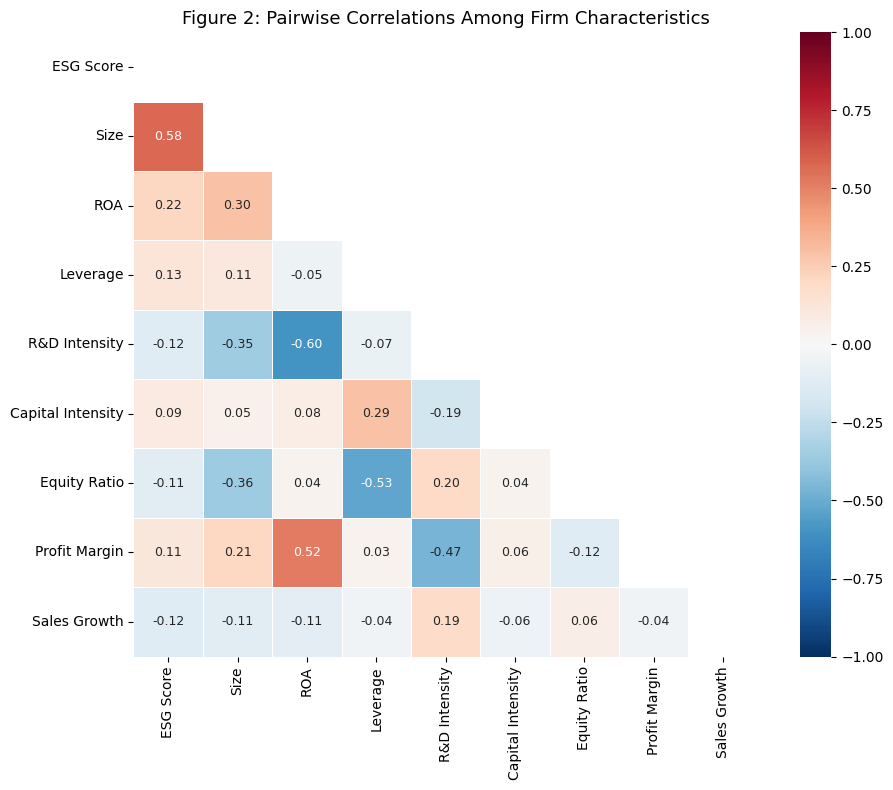

Figure 2 saved to part2_figure2_correlation.png

Table: Pairwise Correlations (lower triangle)


,ESG Score,Size,ROA,Leverage,R&D Intensity,Capital Intensity,Equity Ratio,Profit Margin,Sales Growth
ESG Score,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Size,0.576,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ROA,0.216,0.296,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Leverage,0.133,0.108,-0.049,NaN,NaN,NaN,NaN,NaN,NaN
R&D Intensity,-0.118,-0.354,-0.596,-0.067,NaN,NaN,NaN,NaN,NaN
Capital Intensity,0.092,0.054,0.078,0.295,-0.191,NaN,NaN,NaN,NaN
Equity Ratio,-0.112,-0.364,0.038,-0.526,0.202,0.038,NaN,NaN,NaN
Profit Margin,0.112,0.210,0.516,0.033,-0.466,0.057,-0.119,NaN,NaN
Sales Growth,-0.119,-0.113,-0.105,-0.043,0.195,-0.062,0.064,-0.043,NaN


In [9]:
corr_vars = [
    'esg_score', 'size', 'roa',
    'leverage', 'rd_intensity', 'capital_intensity',
    'equity_ratio', 'profit_margin', 'sales_growth',
]
corr_labels = [
    'ESG Score', 'Size', 'ROA',
    'Leverage', 'R&D Intensity', 'Capital Intensity',
    'Equity Ratio', 'Profit Margin', 'Sales Growth',
]

corr_data = panel[corr_vars].dropna()
corr_matrix = corr_data.corr()
corr_matrix.index   = corr_labels
corr_matrix.columns = corr_labels

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

if HAS_SEABORN:
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        corr_matrix,
        mask=mask,
        annot=True, fmt='.2f',
        cmap='RdBu_r', vmin=-1, vmax=1, center=0,
        square=True, linewidths=0.5,
        annot_kws={'size': 9},
        ax=ax
    )
    ax.set_title('Figure 2: Pairwise Correlations Among Firm Characteristics', fontsize=13)
    plt.tight_layout()
    plt.savefig('part2_figure2_correlation.png', bbox_inches='tight', dpi=150)
    plt.show()
else:
    # Fallback: matplotlib imshow without the upper triangle
    masked_corr = corr_matrix.values.copy()
    masked_corr[np.triu_indices_from(masked_corr)] = np.nan
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(masked_corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(len(corr_labels)))
    ax.set_yticks(range(len(corr_labels)))
    ax.set_xticklabels(corr_labels, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(corr_labels, fontsize=9)
    for i in range(len(corr_labels)):
        for j in range(i):
            ax.text(i, j, f'{corr_matrix.iloc[j, i]:.2f}',
                    ha='center', va='center', fontsize=8)
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title('Figure 2: Pairwise Correlations Among Firm Characteristics', fontsize=13)
    plt.tight_layout()
    plt.savefig('part2_figure2_correlation.png', bbox_inches='tight', dpi=150)
    plt.show()

print('Figure 2 saved to part2_figure2_correlation.png')

# Also print the correlation table for use in the report
print('\nTable: Pairwise Correlations (lower triangle)')
display(corr_matrix.where(~mask).round(3))

Figure 2 and the accompanying correlation table document the pairwise associations among the variables. The ESG-size correlation of 0.576 is the largest in the matrix by a wide margin, confirming that size is the dominant factor. ESG is also positively correlated with ROA (0.216) and, somewhat counter-intuitively, with leverage (0.133). As discussed in the context of Figure 1, the positive leverage-ESG correlation reflects industry composition: regulated, capital-intensive industries carry high debt and score well on ESG. Both R&D intensity (-0.118) and the equity ratio (-0.112) are negatively correlated with ESG, for reasons related to pharmaceutical industry composition and the association of high equity ratios with loss-making growth firms, respectively.

Among the regressors, the most notable inter-predictor correlation is between R&D intensity and ROA (-0.596): firms with heavy R&D spending tend to report lower current profitability, as R&D is expensed immediately under US GAAP. This suggests that including both variables in the same regression may attenuate the individual coefficients, though both remain theoretically distinct. Leverage and the equity ratio are negatively correlated (-0.526), as expected from accounting structure. No other pairwise correlation among regressors exceeds 0.40 in absolute value, which mitigates severe multicollinearity concerns beyond the R&D-ROA pair.

## 4. Regression Analysis: What Predicts ESG Scores?

We estimate ordinary least squares regressions of ESG scores on firm characteristics. Four models are reported. Model 1 is a baseline specification that includes only firm size with year fixed effects. Model 2 adds profitability and financial structure variables. Model 3 includes the full set of eight characteristics with year fixed effects. Model 4 is the preferred specification and augments Model 3 with Fama-French 48 industry fixed effects, which absorb any time-invariant industry-level variation in ESG scores and allow the coefficients to be interpreted as within-industry effects of firm characteristics on ESG.

Standard errors are clustered at the firm level in all specifications to account for the serial correlation of ESG scores within firms over time. The regression sample is restricted to firm-years with non-missing values for all eight characteristics, which primarily affects observations lacking lagged sales data.

In [10]:
reg_vars = [
    'esg_score', 'size', 'roa',
    'leverage', 'rd_intensity', 'capital_intensity',
    'equity_ratio', 'profit_margin', 'sales_growth',
    'ff48_id', 'fyear', 'gvkey'
]
panel_reg = panel[reg_vars].dropna().copy()
panel_reg['gvkey_str'] = panel_reg['gvkey'].astype(str)
panel_reg['ff48_id']   = panel_reg['ff48_id'].astype(int)

print(f'Regression sample: {len(panel_reg):,} firm-year observations')

# Model 1: baseline (size + year FE)
# Model 2: add profitability and financial structure (size + ROA + leverage + R&D + year FE)
# Model 3: full characteristics + year FE
# Model 4: full characteristics + year FE + industry FE (preferred specification)

formulas = {
    '(1)': 'esg_score ~ size + C(fyear)',
    '(2)': (
        'esg_score ~ size + roa + leverage + rd_intensity'
        ' + C(fyear)'
    ),
    '(3)': (
        'esg_score ~ size + roa + leverage + rd_intensity'
        ' + capital_intensity + profit_margin + sales_growth + equity_ratio'
        ' + C(fyear)'
    ),
    '(4)': (
        'esg_score ~ size + roa + leverage + rd_intensity'
        ' + capital_intensity + profit_margin + sales_growth + equity_ratio'
        ' + C(fyear) + C(ff48_id)'
    ),
}

results = {}
for key, formula in formulas.items():
    mod = smf.ols(formula, data=panel_reg)
    res = mod.fit(
        cov_type='cluster',
        cov_kwds={'groups': panel_reg['gvkey_str']}
    )
    results[key] = res
    print(f'Model {key}: N = {int(res.nobs):,}, R-squared = {res.rsquared:.4f}')

Regression sample: 16,962 firm-year observations
Model (1): N = 16,962, R-squared = 0.3514
Model (2): N = 16,962, R-squared = 0.3824
Model (3): N = 16,962, R-squared = 0.4080
Model (4): N = 16,962, R-squared = 0.4810


In [11]:
def build_reg_table(results_dict, var_display, fe_info):
    """
    Construct a regression table in the style of academic finance journals.

    Each variable occupies two rows: the coefficient (with significance stars)
    and the clustered standard error in parentheses below it. The bottom panel
    reports sample size, R-squared, and fixed effect indicators.

    Parameters
    ----------
    results_dict : dict {model_name: statsmodels OLS result}
    var_display  : dict {statsmodels variable name: display label}
    fe_info      : dict {model_name: {'Year FE': str, 'Industry FE': str}}

    Returns
    -------
    pandas DataFrame suitable for display and export
    """
    model_names = list(results_dict.keys())
    rows = []

    for varname, label in var_display.items():
        coef_row = {'Variable': label}
        se_row   = {'Variable': ''}
        for mname in model_names:
            res = results_dict[mname]
            if varname in res.params.index:
                coef = res.params[varname]
                se   = res.bse[varname]
                pval = res.pvalues[varname]
                stars = (
                    '***' if pval < 0.01 else
                    '**'  if pval < 0.05 else
                    '*'   if pval < 0.10 else ''
                )
                coef_row[mname] = f'{coef:.4f}{stars}'
                se_row[mname]   = f'({se:.4f})'
            else:
                coef_row[mname] = ''
                se_row[mname]   = ''
        rows.append(coef_row)
        rows.append(se_row)

    # Bottom panel
    rows.append({'Variable': 'N',
                 **{m: f"{int(results_dict[m].nobs):,}" for m in model_names}})
    rows.append({'Variable': 'R-squared',
                 **{m: f"{results_dict[m].rsquared:.4f}" for m in model_names}})
    rows.append({'Variable': 'Year FE',
                 **{m: fe_info[m]['Year FE'] for m in model_names}})
    rows.append({'Variable': 'Industry FE',
                 **{m: fe_info[m]['Industry FE'] for m in model_names}})

    df = pd.DataFrame(rows).set_index('Variable')
    df.index.name = None
    return df


var_display = {
    'size':              'Size (log AT)',
    'roa':               'Return on Assets',
    'leverage':          'Leverage',
    'rd_intensity':      'R&D Intensity',
    'capital_intensity': 'Capital Intensity',
    'profit_margin':     'Profit Margin',
    'sales_growth':      'Sales Growth',
    'equity_ratio':      'Equity Ratio',
}

fe_info = {
    '(1)': {'Year FE': 'Yes', 'Industry FE': 'No'},
    '(2)': {'Year FE': 'Yes', 'Industry FE': 'No'},
    '(3)': {'Year FE': 'Yes', 'Industry FE': 'No'},
    '(4)': {'Year FE': 'Yes', 'Industry FE': 'Yes'},
}

reg_table = build_reg_table(results, var_display, fe_info)

print('Table 2: Determinants of ESG Performance (OLS)')
print('Dependent variable: ESG Score (winsorized at 1st and 99th percentiles)')
print('Standard errors clustered by firm in parentheses.')
print('Significance: *** p < 0.01, ** p < 0.05, * p < 0.10')
display(reg_table)

Table 2: Determinants of ESG Performance (OLS)
Dependent variable: ESG Score (winsorized at 1st and 99th percentiles)
Standard errors clustered by firm in parentheses.
Significance: *** p < 0.01, ** p < 0.05, * p < 0.10


,(1),(2),(3),(4)
Size (log AT),0.0621***,0.0632***,0.0687***,0.0725***
,(0.0014),(0.0015),(0.0016),(0.0016)
Return on Assets,,0.2332***,0.1787***,0.1201***
,,(0.0185),(0.0199),(0.0188)
Leverage,,0.0725***,0.1309***,-0.0170
,,(0.0120),(0.0152),(0.0179)
R&D Intensity,,0.4533***,0.4336***,0.2425***
,,(0.0340),(0.0355),(0.0393)
Capital Intensity,,,0.0242*,-0.0017
,,,(0.0131),(0.0188)


Table 2 reports the regression results. Across all four specifications, firm size carries a large, positive, and statistically significant coefficient. In the preferred specification (Model 4), a one-unit increase in log total assets is associated with a 0.073-point increase in ESG score (standard error 0.0016). This coefficient is stable across models, rising slightly as additional controls are added, and is unaffected by the inclusion of industry fixed effects. The robustness of the size effect confirms that it is not merely capturing industry-level differences in firm scale.

Return on assets is positive and significant in Models 2 through 4, with the coefficient declining from 0.233 in Model 2 to 0.120 in Model 4 as industry effects and additional controls absorb common variation. This supports the slack resources hypothesis: firms generating higher earnings have more discretionary capacity to invest in ESG activities, and this relationship holds within industries.

The leverage result is striking. In Models 2 and 3, leverage carries a positive and significant coefficient, consistent with the univariate finding that leveraged regulated industries have high ESG scores. However, once industry fixed effects are added in Model 4, the leverage coefficient becomes small and statistically insignificant (-0.017, standard error 0.018). This indicates that the positive unconditional association between leverage and ESG is entirely explained by industry composition: utilities, restaurants, and similarly regulated sectors happen to be both heavily leveraged and high-ESG. Within industries, leverage does not predict ESG performance.

R&D intensity is positive and significant in all models, including Model 4, where the coefficient is 0.243 (standard error 0.039). This finding is the inverse of the raw negative correlation noted earlier. Once the pharmaceutical industry's low ESG scores are absorbed by industry fixed effects, within-industry variation in R&D spending is positively associated with ESG, consistent with the view that innovation-oriented firms also invest more in social and governance practices.

Capital intensity is borderline significant in Model 3 (coefficient 0.024, significant at the ten percent level) but loses significance entirely in Model 4, suggesting its unconditional effect on ESG is also driven by between-industry variation rather than within-industry differences.

Sales growth is negative and significant in both Models 3 and 4 (coefficient -0.035 in Model 4, standard error 0.004). This finding is consistent with the idea that rapidly growing firms have not yet built the organizational infrastructure required for mature ESG programs. Fast growth may also be associated with younger firms in sectors with lower baseline ESG engagement.

The equity ratio and profit margin are not significant in Model 4. Their apparent effects in Model 3 are absorbed by industry fixed effects, suggesting they are proxying for industry-level differences in capital structure and margin profiles rather than capturing independent within-industry variation.

The R-squared rises from 0.351 in the baseline model to 0.408 in the full model without industry fixed effects, and then to 0.481 once industry dummies are added. The 7-percentage-point increase attributable to industry fixed effects indicates that a meaningful share of cross-sectional ESG variation reflects persistent industry-level characteristics that are not captured by the firm-level financial variables alone.

## 5. Industry-Level Variation in ESG Determinants

The regression results in Section 4 confirm that industry fixed effects explain a substantial share of ESG score variation. In this section, we examine the industry-level distribution of the main determinants to understand which industries combine high ESG scores with particular profiles of firm characteristics. Table 3 reports industry-level means for all variables, restricted to industries with at least 50 firm-year observations. Figure 3a plots mean ESG scores against mean firm size, with bubble color encoding mean leverage. Figure 3b plots mean ESG scores against mean R&D intensity, with bubble color encoding mean capital intensity. Together, the two panels allow visual identification of industries where high ESG coincides with or diverges from the characteristic profiles predicted by the regression.

In [12]:
agg_dict = {
    'N':                 ('esg_score',       'count'),
    'Mean ESG':          ('esg_score',       'mean'),
    'Mean Size':         ('size',            'mean'),
    'Mean ROA':          ('roa',             'mean'),
    'Mean Leverage':     ('leverage',        'mean'),
    'Mean R&D Intensity':('rd_intensity',    'mean'),
    'Mean Cap. Intensity':('capital_intensity','mean'),
    'Mean Equity Ratio': ('equity_ratio',    'mean'),
}

ind_chars = panel.groupby('industry').agg(**agg_dict).round(3)
ind_chars = ind_chars[ind_chars['N'] >= 50].sort_values('Mean ESG', ascending=False)

print('Table 3: Industry-Level Mean Firm Characteristics (industries with N >= 50 firm-years)')
display(ind_chars)

Table 3: Industry-Level Mean Firm Characteristics (industries with N >= 50 firm-years)


,N,Mean ESG,Mean Size,Mean ROA,Mean Leverage,Mean R&D Intensity,Mean Cap. Intensity,Mean Equity Ratio
industry,,,,,,,,
Precious Metals,52,0.518,7.501,-0.068,0.204,0.000,0.620,0.570
Utilities,730,0.514,9.355,0.017,0.383,0.000,0.694,0.289
Restaurants & Hotels,74,0.513,8.490,0.032,0.417,0.008,0.240,0.262
Beer & Liquor,65,0.512,8.839,0.087,0.303,0.002,0.271,0.476
Chemicals,448,0.485,8.007,0.036,0.339,0.021,0.320,0.384
Food Products,398,0.475,8.243,0.061,0.309,0.004,0.231,0.433
Measuring Instruments,335,0.468,7.861,0.034,0.228,0.069,0.104,0.538
Apparel,228,0.466,7.807,0.066,0.267,0.002,0.196,0.470
Aircraft,126,0.462,8.869,0.029,0.345,0.026,0.145,0.297


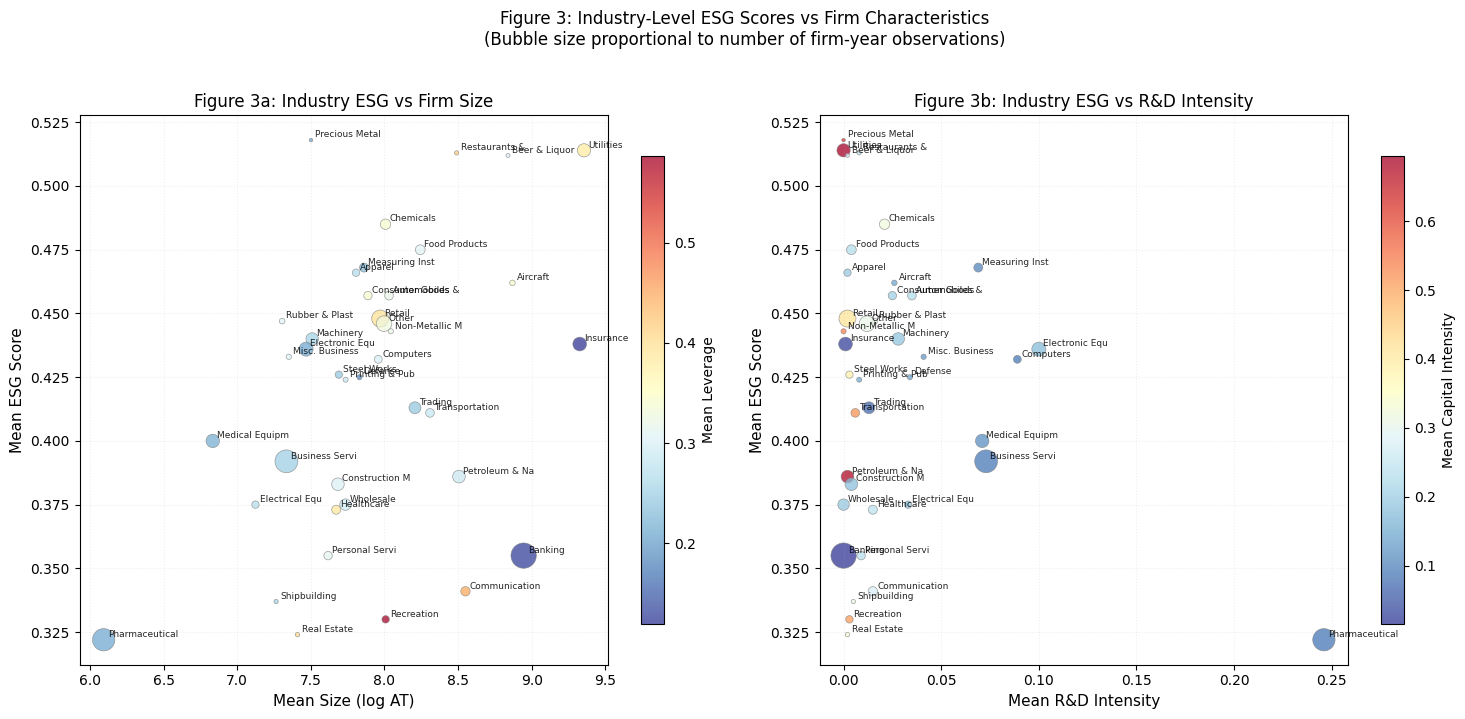

Figure 3 saved to part2_figure3_industry_scatter.png


In [13]:
ind_plot = ind_chars.copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Figure 3a: industry mean size vs mean ESG
# Bubble area proportional to observation count; color encodes mean leverage
sc1 = axes[0].scatter(
    ind_plot['Mean Size'],
    ind_plot['Mean ESG'],
    s=ind_plot['N'] / 8,
    c=ind_plot['Mean Leverage'],
    cmap='RdYlBu_r',
    alpha=0.75,
    edgecolors='grey',
    linewidth=0.5
)
cbar1 = plt.colorbar(sc1, ax=axes[0], shrink=0.85)
cbar1.set_label('Mean Leverage', fontsize=10)
for ind_name, row in ind_plot.iterrows():
    axes[0].annotate(
        ind_name[:14],
        (row['Mean Size'], row['Mean ESG']),
        fontsize=6.5, alpha=0.85,
        xytext=(3, 2), textcoords='offset points'
    )
axes[0].set_xlabel('Mean Size (log AT)', fontsize=11)
axes[0].set_ylabel('Mean ESG Score', fontsize=11)
axes[0].set_title('Figure 3a: Industry ESG vs Firm Size', fontsize=12)
axes[0].grid(True, alpha=0.2, linestyle=':')

# Figure 3b: industry mean R&D intensity vs mean ESG
# Bubble area proportional to observation count; color encodes mean capital intensity
sc2 = axes[1].scatter(
    ind_plot['Mean R&D Intensity'],
    ind_plot['Mean ESG'],
    s=ind_plot['N'] / 8,
    c=ind_plot['Mean Cap. Intensity'],
    cmap='RdYlBu_r',
    alpha=0.75,
    edgecolors='grey',
    linewidth=0.5
)
cbar2 = plt.colorbar(sc2, ax=axes[1], shrink=0.85)
cbar2.set_label('Mean Capital Intensity', fontsize=10)
for ind_name, row in ind_plot.iterrows():
    axes[1].annotate(
        ind_name[:14],
        (row['Mean R&D Intensity'], row['Mean ESG']),
        fontsize=6.5, alpha=0.85,
        xytext=(3, 2), textcoords='offset points'
    )
axes[1].set_xlabel('Mean R&D Intensity', fontsize=11)
axes[1].set_ylabel('Mean ESG Score', fontsize=11)
axes[1].set_title('Figure 3b: Industry ESG vs R&D Intensity', fontsize=12)
axes[1].grid(True, alpha=0.2, linestyle=':')

plt.suptitle(
    'Figure 3: Industry-Level ESG Scores vs Firm Characteristics\n'
    '(Bubble size proportional to number of firm-year observations)',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.savefig('part2_figure3_industry_scatter.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure 3 saved to part2_figure3_industry_scatter.png')

Figure 3a reveals that the positive association between firm size and ESG is present but imperfect at the industry level. Utilities (mean size 9.36, mean ESG 0.514) and insurance (mean size 9.33, mean ESG 0.438) are the two largest-sized industries in the sample and both score above the sample mean, consistent with the size-ESG gradient. Banking, however, is the notable outlier: with a mean size of 8.95 and 2,662 firm-year observations, it is one of the largest-firm industries in the sample yet scores well below the sample mean at 0.355. This divergence from the general size-ESG pattern suggests that, for banking, institutional scale does not translate into strong ESG performance; the industry faces distinct criticisms around governance, social lending practices, and systemic risk that suppress scores despite the size of covered firms.

Figure 3b highlights the pharmaceutical industry as the most striking outlier on R&D intensity. With a mean R&D intensity of 0.246 and the lowest ESG score in the sample (0.322), pharmaceuticals illustrate a sector where high innovation investment coexists with persistent ESG deficits, primarily concentrated in the social pillar through drug pricing and access-to-medicine controversies. By contrast, utilities and restaurants and hotels, which spend effectively nothing on R&D (mean R&D intensity of 0.000 and 0.008, respectively), rank second and third in the sample on mean ESG score (0.514 and 0.513), behind only precious metals (0.518), driven by their regulatory environment and service-oriented workforce practices rather than innovation.

The color gradients in Figure 3 further illustrate that industries with high capital intensity, such as utilities (0.694) and petroleum and natural gas (0.681), do not uniformly translate physical asset exposure into ESG performance: utilities score 0.514 while petroleum and natural gas scores only 0.386. The gap is likely attributable to the difference in regulatory regimes: utilities operate under rate-of-return regulation that creates systematic ESG reporting obligations, whereas oil and gas firms face a more adversarial regulatory environment and greater reputational pressure concentrated on environmental controversies.

Taken together, the regression and industry-level findings indicate that ESG performance is systematically related to firm-level financial characteristics and industry context, but the within-industry determinants are narrower than the unconditional patterns suggest. Firm size and profitability are the most reliable within-industry predictors. Leverage, capital intensity, and the equity ratio appear significant in pooled regressions because they are correlated with industry affiliation rather than because they reflect firm-level decisions about ESG investment within a given sector. Sales growth is the one exception: faster-growing firms score lower on ESG within industries, suggesting a negative relationship between firm dynamism and ESG maturity that is not simply a compositional artifact. These findings have implications for interpreting ESG scores as proxies for genuine sustainability commitment: a firm's high ESG score may reflect, at least in part, its size and the regulatory obligations of its sector rather than a discretionary choice to prioritize environmental, social, and governance practices.